In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import os

#Geometry creation
from APC_Reader import APC_Reader
from BEMT_Blade import BEMT_Blade

#BEMT Analysis
from BEMT_Solver import PropellerParameters, PropellerAnalysis

#Acoustic Analysis
from Acoustic_Solver import CompactSourceElement, AcousticObserver 
from Observer_Manager import ObserverManager

#UIUC
"""import sys
sys.path.append('./Measurement Interpretation')
from UI"""

"import sys\nsys.path.append('./Measurement Interpretation')\nfrom UI"

## GEOMETRY READER

In [2]:
"""READ PROPELLER GEOMETRY AND EXTRACT BEMT INPUT"""
propeller_name = "10x8E"
reader = APC_Reader(os.getcwd() + fr"\APC Propeller Geometry Data\{propeller_name}-PERF.PE0")

In [3]:
"""CONSTRUCT DATA FOR SIMULATION"""
blade = BEMT_Blade(reader, interpolation_points=200)
BEMT_input = blade.export_geometry_for_analysis()

## BEMT ANALYSIS

In [4]:
"""BEMT analysis"""
# Global Propeller Parameters
prop_radius = BEMT_input['tip_radius']
hub_radius = BEMT_input['hub_radius']
n_blades = BEMT_input['n_blades']

# Operating conditions
RPM = 7000
v_inf = 0

# Fluid Parameters
rho = 1.225
mu = 1.81e-5
a_inf = 343

# Define propeller parameters
propeller_parameters = PropellerParameters(
    prop_radius=prop_radius,
    hub_radius=hub_radius,
    n_blades=n_blades,
    RPM=RPM,
    v_inf=v_inf,
    a_inf=a_inf,
    rho=rho,
    mu=mu
)

# Define propeller analysis
propeller_analysis = PropellerAnalysis(
    propeller_geometry=BEMT_input,
    propeller_params=propeller_parameters
)

# Run propeller analysis
n_jobs = 8
propeller_analysis.run_BEMT(n_jobs=n_jobs)

c:\Users\SchneiderMarco\OneDrive - ETH Zurich\ETH\Doktorat\02_Bazl\Low_Fidelity_Approach_git\PropGeom-Sim\BEMT_Solver.py:134: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.solution_data = pd.concat([self.solution_data, pd.DataFrame([[r, chord, theta, phi, alpha, Cl, Cd, a, a_prime, dT, dQ, F, V, Re]], columns=self.solution_data.columns)], ignore_index=True)


## ACOUTSTIC ANALYSIS

In [5]:
#Temporal discretization in observer coordinate system
revolutions = 6
omega = 2*np.pi * RPM/60
duration = revolutions * (2*np.pi/omega) 
blade_passing_period = duration / revolutions / n_blades
observer_time_range = revolutions*blade_passing_period
num_obs_times = 50*revolutions

#Temporal discretization in source coordinate system
n_source_times = 2*num_obs_times
dt = duration/(n_source_times-1)
src_times = np.arange(0,n_source_times)*dt

#Prepare data for acoustic analysis
radial_section = BEMT_input['r']
n_sections = len(radial_section)
dr = BEMT_input['dr']
blade_angles = 2*np.pi/n_blades * np.arange(0, n_blades)
airfoil_area = []
COM_x = []
COM_y = []
for i in range(len(BEMT_input['airfoil'])):
        #airfoil_area.append(BEMT_input['airfoil'][i]._APC_cross_section_area * 0.0254**2)
        airfoil_area.append(BEMT_input['airfoil'][i].calculate_cross_section_area() * BEMT_input['chord'][i]**2)
        COM_x.append(BEMT_input['COM_shift'][i][0])
        COM_y.append(BEMT_input['COM_shift'][i][1])
dT = propeller_analysis.solution_data['dT'] / BEMT_input['dr'] / n_blades
dQ = propeller_analysis.solution_data['dQ'] / BEMT_input['dr'] / BEMT_input['r'] / n_blades
dR = np.zeros_like(dT)

In [13]:
#Define acoustic observer object
r_observer = [[0, 1.8, 0],
              [1.8, 0, 0],
              [0, 0, 1.8]]
observer_manager = ObserverManager().from_positions(r_observer)


for observer in observer_manager:

    #Construct compact source elements, apply coordinate transformation from \nu to y-frame, compute observer times for all compact elements and perform f1a calculation
    compact_source_elements = np.empty((n_source_times, n_sections, n_blades), dtype=object)
    observer_time = np.empty((n_source_times, n_sections, n_blades), dtype=float)
    F1A_output = np.empty((n_source_times, n_sections, n_blades), dtype=object)

    for i in range(n_source_times):
        for j in range(n_sections):
            for k in range(n_blades):
                #compact source element
                element = CompactSourceElement.from_params(
                    rho, a_inf, radial_section[j], blade_angles[k], COM_x[j], COM_y[j], dr[j], airfoil_area[j] , -dT[j] , dR[j], dQ[j], src_times[i]
                )
                compact_source_elements[i,j,k] = element.coordinate_transform(omega=omega, v_inf=v_inf)

                #observer time
                obs_time = element.time_to_observer(observer)
                observer_time[i,j,k] = obs_time

                #f1a calculation
                f1a_output = element.f1a_calculation(element, observer, obs_time)
                F1A_output[i,j,k] = f1a_output

    #combine the source elements at the observer position
    observer.combine_source_elements(f1a_output=F1A_output, time_range=observer_time_range, n_common_time_steps=num_obs_times)

c:\Users\SchneiderMarco\OneDrive - ETH Zurich\ETH\Doktorat\02_Bazl\Low_Fidelity_Approach_git\PropGeom-Sim\Acoustic_Solver.py:210: RuntimeWarning: divide by zero encountered in log10
  A_weight = lambda f: 20 * np.log10(R_a(f)) - 20 * np.log10(R_a(1000))
c:\Users\SchneiderMarco\OneDrive - ETH Zurich\ETH\Doktorat\02_Bazl\Low_Fidelity_Approach_git\PropGeom-Sim\Acoustic_Solver.py:203: RuntimeWarning: divide by zero encountered in log10
  self.SPL = 20 * np.log10(self.fft_pressure_amplitude / AcousticObserver.p_ref)


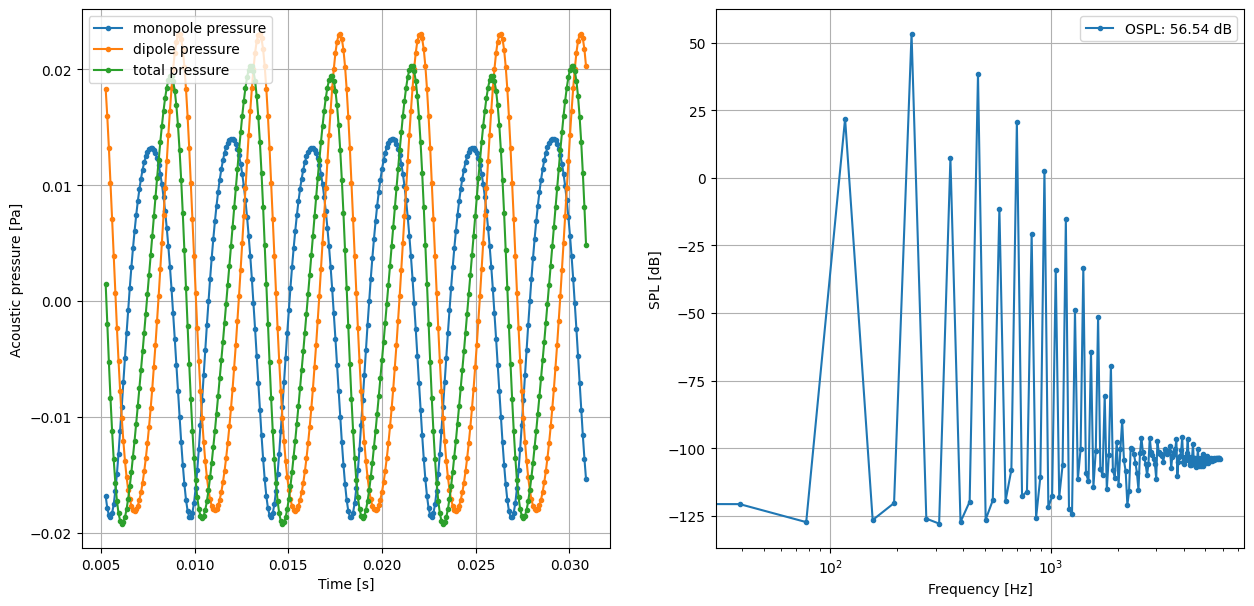

In [16]:
#plot results
observer = observer_manager[2]

%matplotlib inline
fig, axs = plt.subplots(1,2)
fig.set_figheight(7)
fig.set_figwidth(15)
fontsize=10
labelsize=10

axs[0].plot(observer.t, observer.p_m, marker='.', label='monopole pressure')
axs[0].plot(observer.t, observer.p_d, marker='.', label='dipole pressure')
axs[0].plot(observer.t, observer.p_m+observer.p_d, marker='.', label='total pressure')
axs[0].set_xlabel('Time [s]', fontsize=fontsize)
axs[0].set_ylabel('Acoustic pressure [Pa]', fontsize=fontsize)
axs[0].grid(True)
axs[0].legend()

axs[1].semilogx(observer.frequency, observer.SPL, marker='.', label=f'OSPL: {observer.OSPL:.2f} dB')
axs[1].set_xlabel('Frequency [Hz]', fontsize=fontsize)
axs[1].set_ylabel('SPL [dB]', fontsize=fontsize)
axs[1].grid(True)
axs[1].legend()